In [12]:
%reload_ext autoreload
%autoreload 2

import brian2 as b2
import brian2hears as b2h
import sys, os
# Compute the project root automatically
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(PROJECT_ROOT)
simulate_repo = PROJECT_ROOT + '/simulate'
print(simulate_repo)
sys.path.insert(0, simulate_repo)

from simulate.models.BrainstemModel.params import Parameters as params
from utils.anf_utils import ZI_COC_KEY, create_sound_key
from utils.hrtf_utils import run_hrtf, run_hrtf_ircam
from utils.custom_sounds import Click, Tone, WhiteNoise, Click_Train
from utils.cochlea_utils import ANGLES
from analyze.report import plot_sound
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors




/Users/francescodesantis/Documents/repos/sound_localization_model
/Users/francescodesantis/Documents/repos/sound_localization_model/simulate


In [13]:
TIME_SIMULATION = 250
level = 90 * b2h.dB

inputs = [
    Tone(0.2 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(0.5 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(1.2 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(4 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    Tone(16 * b2.kHz, TIME_SIMULATION * b2.ms, level),
    WhiteNoise(TIME_SIMULATION * b2.ms, level),
]
inputs_2 = [Click(duration= TIME_SIMULATION * b2.ms, click_duration=1, level=level),
            Click_Train(duration= TIME_SIMULATION * b2.ms, click_duration=1 * b2.ms, interval=4 * b2.ms, level=level)]

In [14]:
p = params()
print(p)

Parameters(key='default_params', cochlea={'gammatone': {'hrtf_params': {'subj_number': 0, 'ild_only': False, 'itd_remove_strategy': 'computed', 'apply_gating': True, 'ramp_ms': 10}, 'noise_factor': 0.3, 'refractory_period': 1, 'amplif_factor': 7}, 'TanCarney': {'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf', 'apply_gating': True, 'ramp_ms': 10}, 'cochlea_params': None, 'rng_seed': 42, 'omni_noise_level': 0}, 'Zilany': {'hrtf_params': {'subj_number': 0, 'itd_remove_strategy': 'estimate_from_hrtf', 'apply_gating': True, 'ramp_ms': 10}, 'cochlea_params': {'anf_num': (6, 2, 2), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}}, n_ANFs=35000, V_m=-65.0, V_reset=-67.0, SBCs2MSOs=5, SBCs2LSOs=5, n_SBCs=8750, n_GBCs=1750, n_MSOs=1750, n_LSOs=1750, n_inhMSOs=1750)


2025-12-18 17:01:34,026 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,047 [DEBUG]  [run_hrtf] Applying gating before HRTF...


(<Figure size 2000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

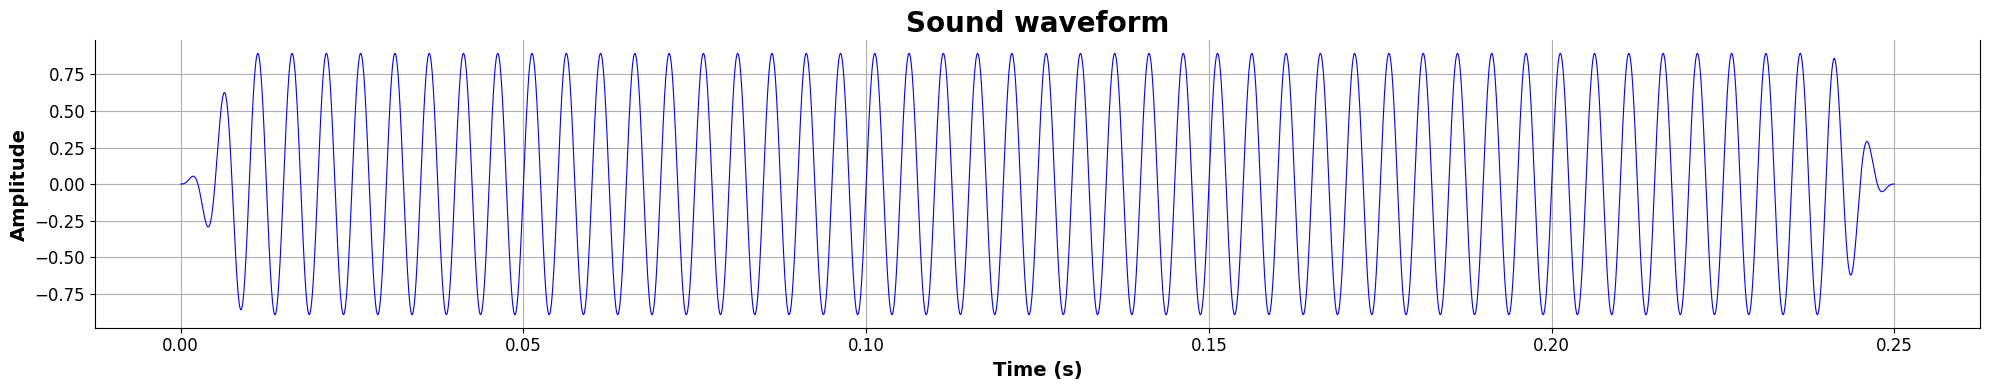

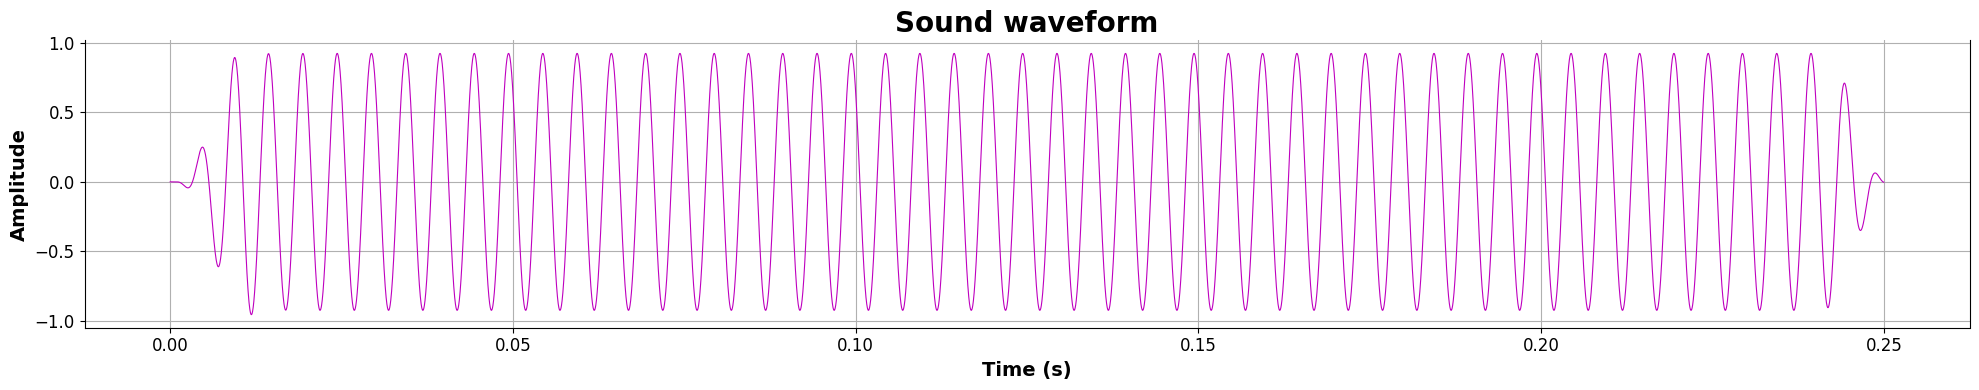

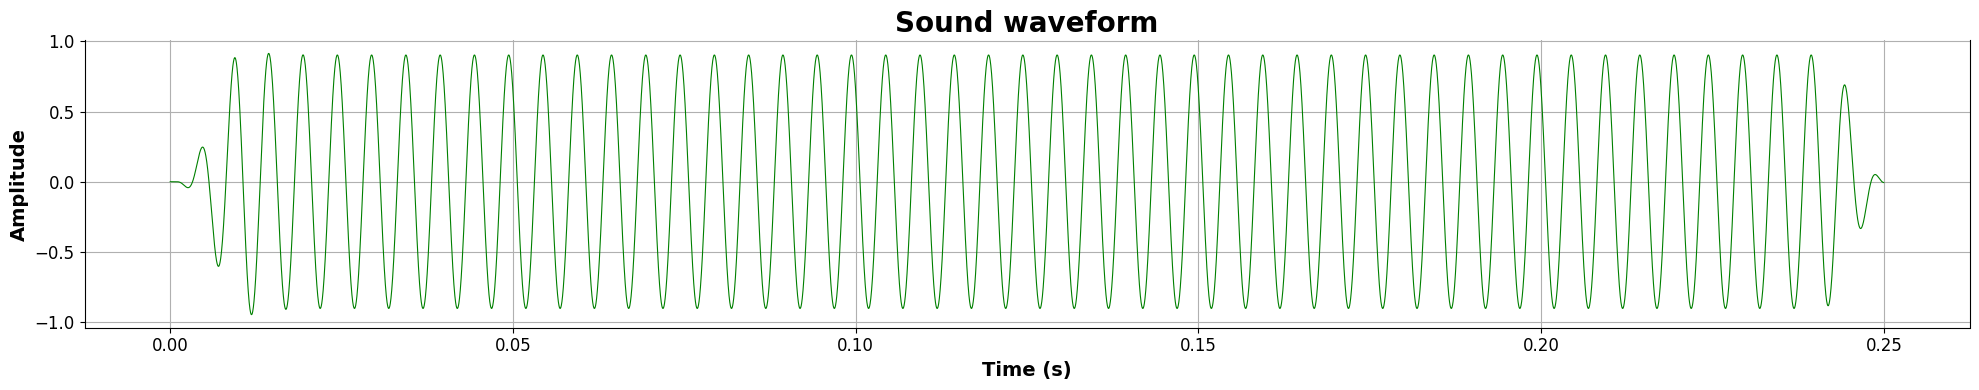

In [15]:
binaural, g = run_hrtf(inputs[0], 0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
plot_sound(g)
plot_sound(binaural.left, color='m')
plot_sound(binaural.right, color='g')

2025-12-18 17:01:34,857 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,858 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:34,862 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,863 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:34,864 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,865 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:34,866 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,867 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:34,868 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,869 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:34,870 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:34,870 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:34,872 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2025-12-18 

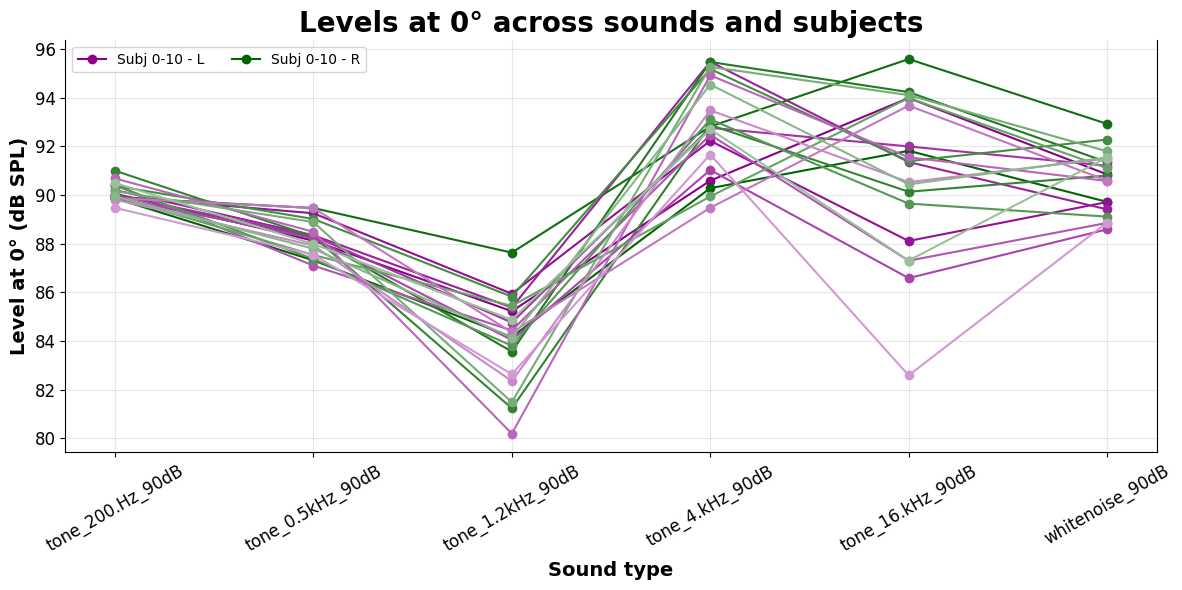

In [ ]:
# pick the angle you want to isolate
ANGLE0 = 0
subjects = range(10)
# --- build shades starting from darkmagenta / darkgreen ---
base_magenta = np.array(mcolors.to_rgb("darkmagenta"))
base_green   = np.array(mcolors.to_rgb("darkgreen"))
white        = np.array([1.0, 1.0, 1.0])

# alpha controls how strong the base color is (1 = darkest, 0 = white)
alphas = np.linspace(1.0, 0.4, len(subjects))  # subj 0 darker, subj 5 lighter

magenta_colors = [tuple(white * (1 - a) + base_magenta * a) for a in alphas]
green_colors   = [tuple(white * (1 - a) + base_green   * a) for a in alphas]

plt.figure(figsize=(12, 6))
plt.title(f"Levels at {ANGLE0}° across sounds and subjects")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

for s_idx, subj in enumerate(subjects):
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    # plot for each subject: L solid, R dashed
    plt.plot(
        x, l_at_0, "o", 
        color=magenta_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - L" if s_idx == 0 else None
    )
    plt.plot(
        x, r_at_0, "o",
        color=green_colors[s_idx],
        label=f"Subj 0-{len(subjects)} - R" if s_idx == 0 else None
    )

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


2025-12-18 17:01:35,744 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:35,745 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:35,748 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:35,749 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:35,750 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:35,751 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:35,753 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:35,753 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:35,754 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:35,755 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:35,756 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:01:35,757 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:35,758 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2025-12-18 

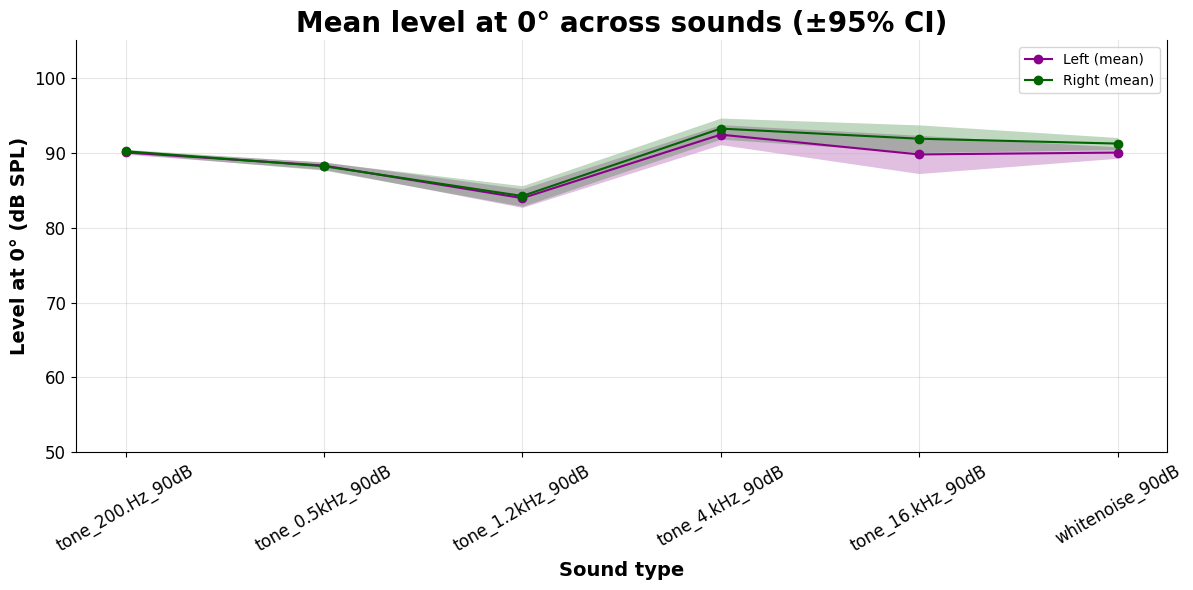

In [17]:
from scipy.stats import t

ANGLE0 = 0

plt.figure(figsize=(12, 6))
plt.title(f"Mean level at {ANGLE0}° across sounds (±95% CI)")

sound_labels = [create_sound_key(s) for s in inputs]
x = np.arange(len(inputs))

# containers: shape = (n_subjects, n_sounds)
L_all = []
R_all = []

for subj in subjects:
    p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

    l_at_0 = []
    r_at_0 = []

    for sound in inputs:
        binaural, g = run_hrtf(sound, ANGLE0, p.cochlea[ZI_COC_KEY]['hrtf_params'])
        l_at_0.append(binaural[:, 0].level)
        r_at_0.append(binaural[:, 1].level)

    L_all.append(l_at_0)
    R_all.append(r_at_0)

L_all = np.array(L_all)  # (subjects, sounds)
R_all = np.array(R_all)

# --- statistics ---
n = len(subjects)
df = n - 1
tval = t.ppf(0.975, df)  # 95% CI

L_mean = L_all.mean(axis=0)
R_mean = R_all.mean(axis=0)

L_sem = L_all.std(axis=0, ddof=1) / np.sqrt(n)
R_sem = R_all.std(axis=0, ddof=1) / np.sqrt(n)

L_ci = tval * L_sem
R_ci = tval * R_sem

# --- plot ---
plt.plot(x, L_mean, "o-", color="darkmagenta", label="Left (mean)")
plt.plot(x, R_mean, "o-", color="darkgreen", label="Right (mean)")

plt.fill_between(
    x, L_mean - L_ci, L_mean + L_ci,
    color="darkmagenta", alpha=0.25, linewidth=0
)
plt.fill_between(
    x, R_mean - R_ci, R_mean + R_ci,
    color="darkgreen", alpha=0.25, linewidth=0
)

plt.xticks(x, sound_labels, rotation=30)
plt.xlabel("Sound type")
plt.ylabel("Level at 0° (dB SPL)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.ylim(50, 105)
plt.show()


2025-12-18 17:01:36,488 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:36,489 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,493 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-12-18 17:01:36,494 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,496 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-12-18 17:01:36,496 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,497 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-12-18 17:01:36,498 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,499 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-12-18 17:01:36,499 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,500 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2025-12-18 17:01:36,502 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,503 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0

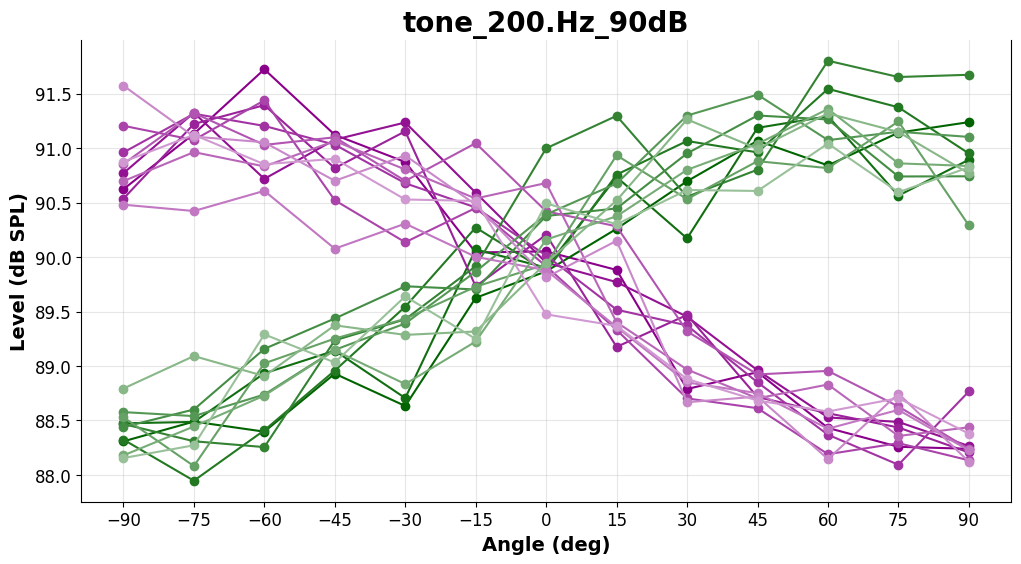

2025-12-18 17:01:36,749 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:36,750 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,753 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-12-18 17:01:36,753 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,754 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-12-18 17:01:36,755 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,755 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-12-18 17:01:36,756 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,757 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-12-18 17:01:36,757 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,758 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2025-12-18 17:01:36,759 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:36,760 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0

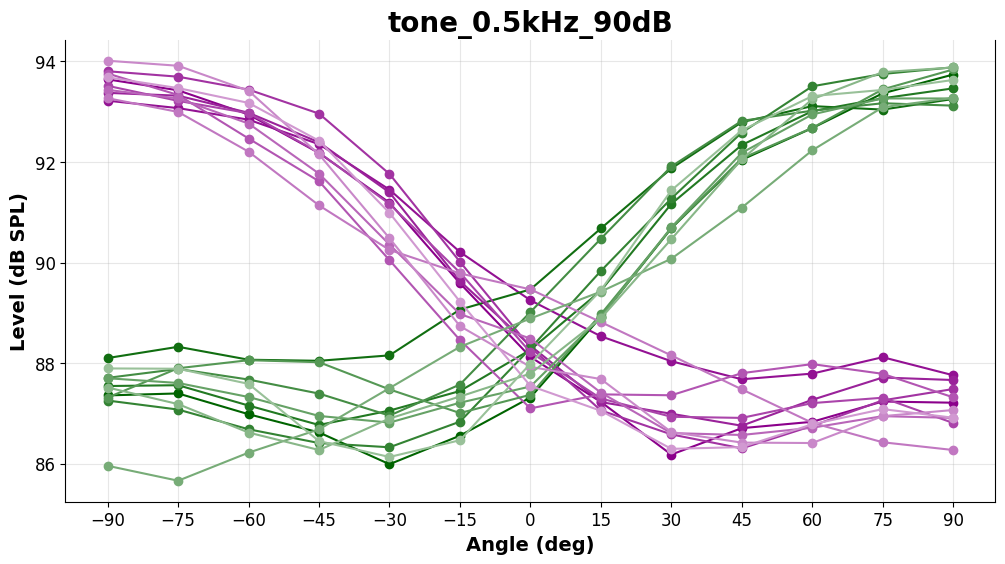

2025-12-18 17:01:37,004 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:37,007 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,016 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-12-18 17:01:37,018 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,020 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-12-18 17:01:37,021 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,022 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-12-18 17:01:37,023 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,026 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-12-18 17:01:37,028 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,031 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2025-12-18 17:01:37,032 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,034 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0

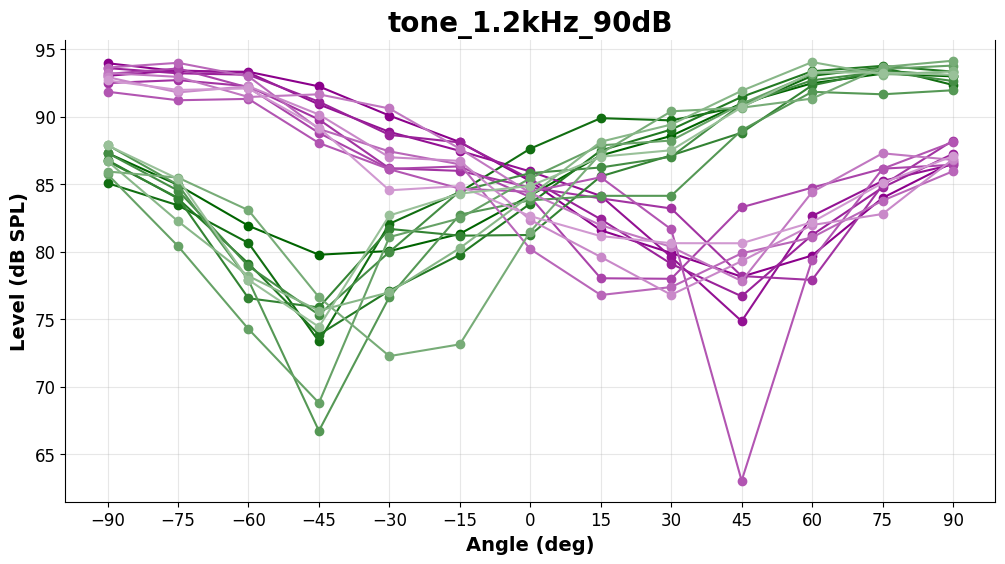

2025-12-18 17:01:37,287 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:37,288 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,290 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-12-18 17:01:37,291 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,292 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-12-18 17:01:37,293 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,294 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-12-18 17:01:37,294 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,295 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-12-18 17:01:37,296 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,297 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2025-12-18 17:01:37,298 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,299 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0

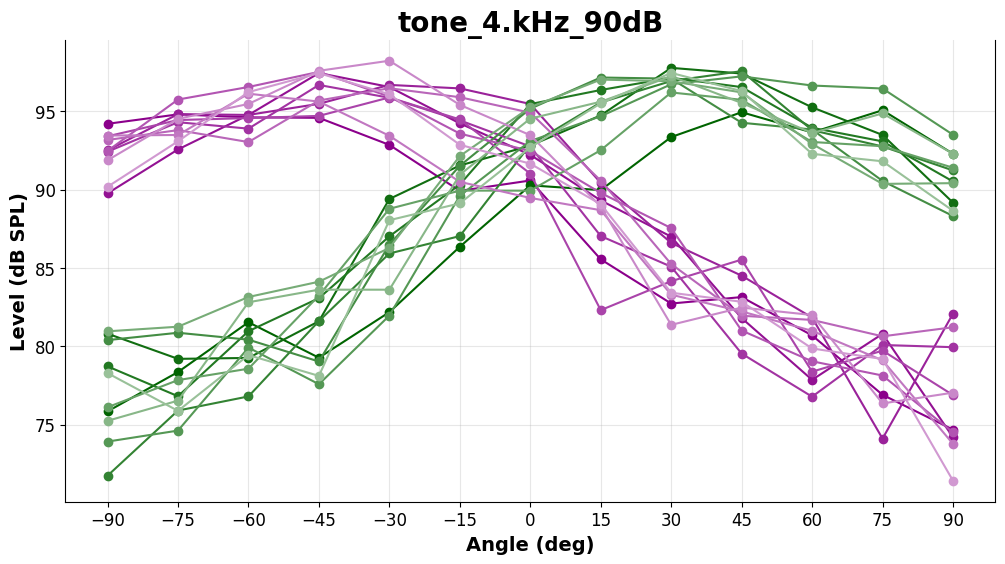

2025-12-18 17:01:37,526 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:37,527 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,529 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-12-18 17:01:37,530 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,531 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-12-18 17:01:37,531 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,532 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-12-18 17:01:37,532 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,533 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-12-18 17:01:37,534 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,534 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2025-12-18 17:01:37,535 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,536 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0

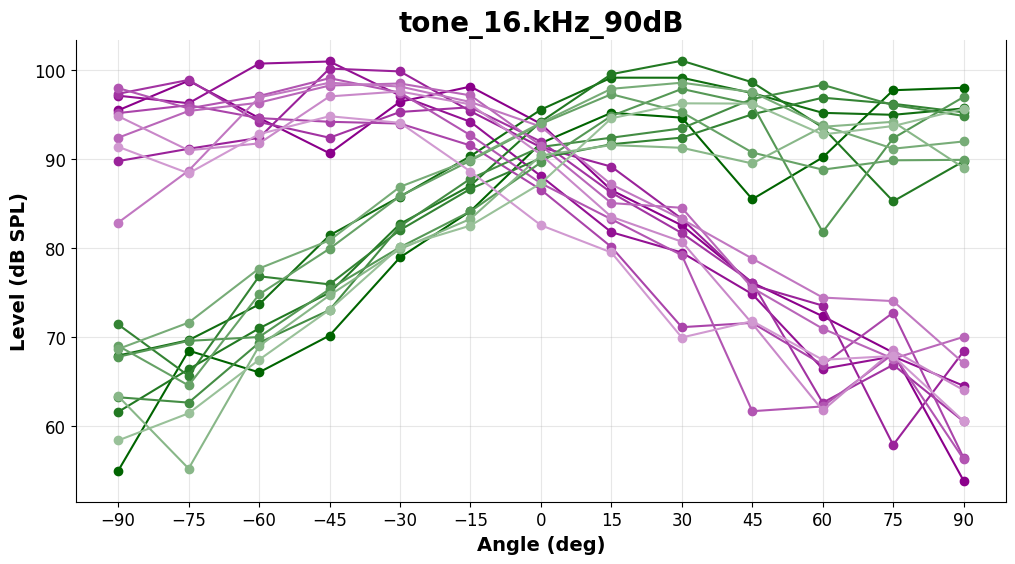

2025-12-18 17:01:37,773 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:37,774 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,775 [DEBUG]  [run_hrtf] Starting HRTF for angle=-75 subj=0
2025-12-18 17:01:37,775 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,776 [DEBUG]  [run_hrtf] Starting HRTF for angle=-60 subj=0
2025-12-18 17:01:37,777 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,778 [DEBUG]  [run_hrtf] Starting HRTF for angle=-45 subj=0
2025-12-18 17:01:37,778 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,779 [DEBUG]  [run_hrtf] Starting HRTF for angle=-30 subj=0
2025-12-18 17:01:37,779 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,780 [DEBUG]  [run_hrtf] Starting HRTF for angle=-15 subj=0
2025-12-18 17:01:37,781 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:37,781 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0

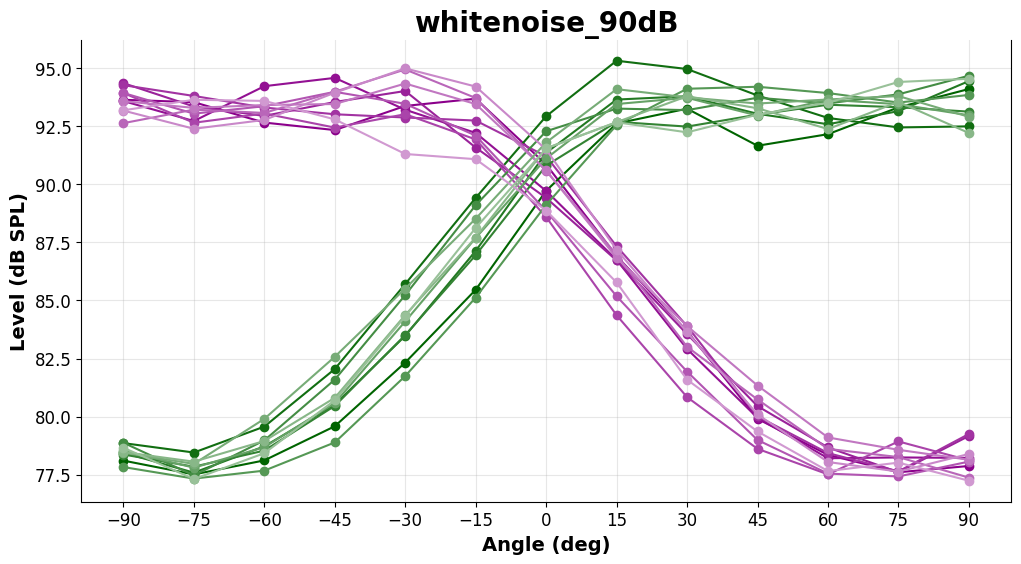

In [18]:
for sound in inputs:
    plt.figure(figsize=(12, 6))
    plt.title(create_sound_key(sound))  # <- only sound name, as requested

    for s_idx, subj in enumerate(subjects):
        p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

        g_levels = []
        l_levels = []
        r_levels = []

        for angle in ANGLES:
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])
            g_levels.append(g.level)
            l_levels.append(binaural[:, 0].level)
            r_levels.append(binaural[:, 1].level)

        # plot: left = magenta shades, right = green shades
        plt.plot(
            ANGLES, l_levels, "o-",
            color=magenta_colors[s_idx],
        )
        plt.plot(
            ANGLES, r_levels, "o-",
            color=green_colors[s_idx],
        )

    plt.xlabel("Angle (deg)")
    plt.ylabel("Level (dB SPL)")
    plt.grid(True, alpha=0.3)
    plt.xticks(ANGLES)
    # legend: one entry for Left and one for Right is usually enough
    plt.show()


2025-12-18 17:01:38,178 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:38,180 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,182 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-18 17:01:38,183 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,184 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-18 17:01:38,185 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,186 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-18 17:01:38,187 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,188 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-18 17:01:38,189 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,191 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-18 17:01:38,192 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,193 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

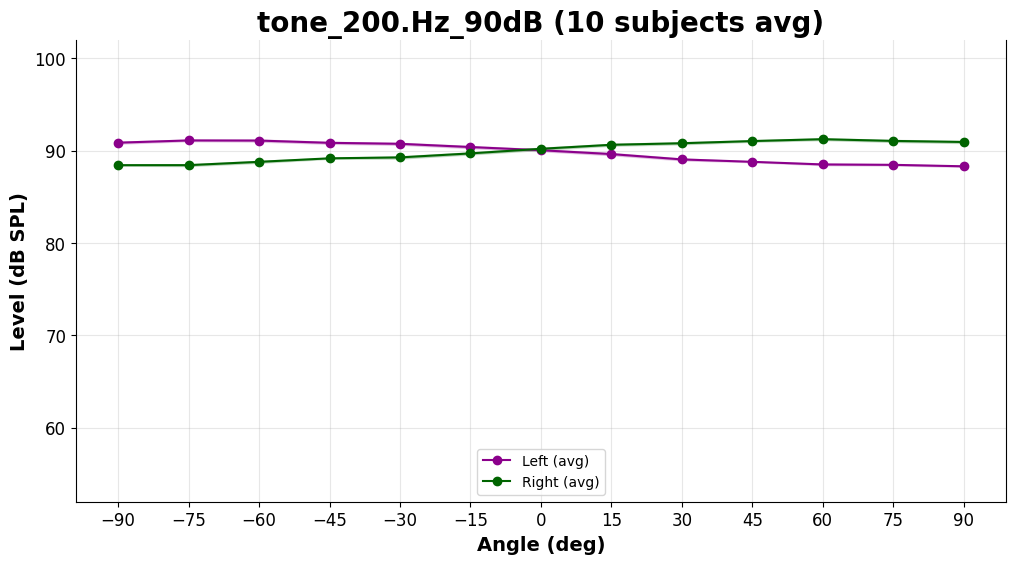

2025-12-18 17:01:38,464 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:38,465 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,466 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-18 17:01:38,467 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,468 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-18 17:01:38,468 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,469 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-18 17:01:38,470 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,471 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-18 17:01:38,471 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,474 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-18 17:01:38,475 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,476 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

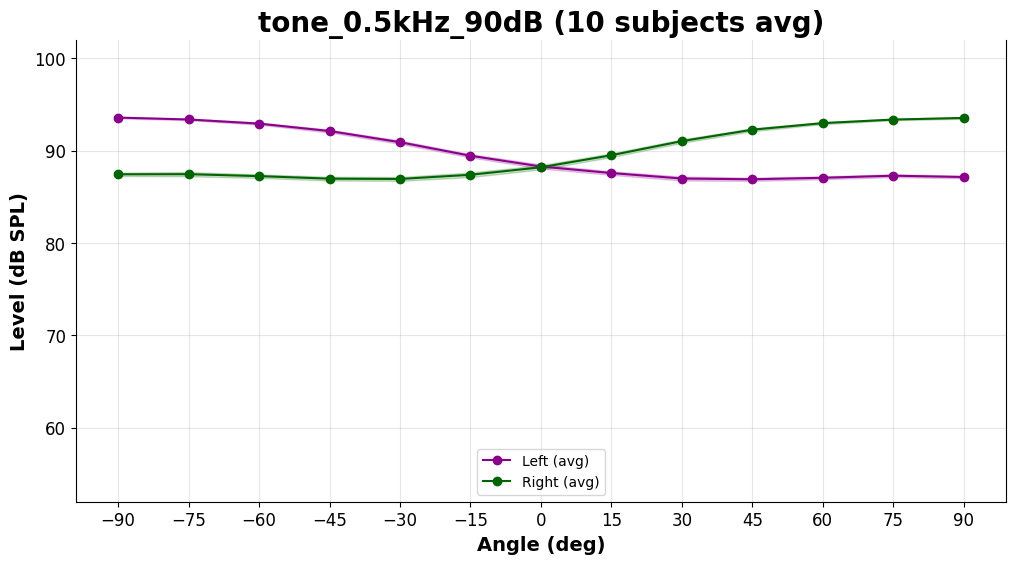

2025-12-18 17:01:38,746 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:38,747 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,748 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-18 17:01:38,749 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,750 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-18 17:01:38,750 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,751 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-18 17:01:38,752 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,753 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-18 17:01:38,754 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,756 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-18 17:01:38,757 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:38,758 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

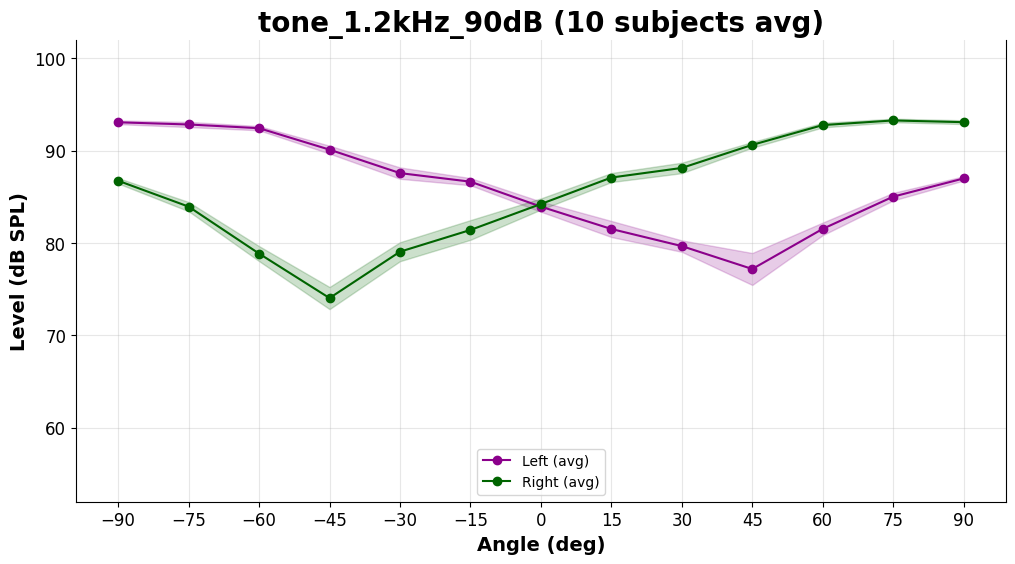

2025-12-18 17:01:39,148 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:39,150 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,153 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-18 17:01:39,154 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,155 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-18 17:01:39,156 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,158 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-18 17:01:39,159 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,161 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-18 17:01:39,162 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,165 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-18 17:01:39,166 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,167 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

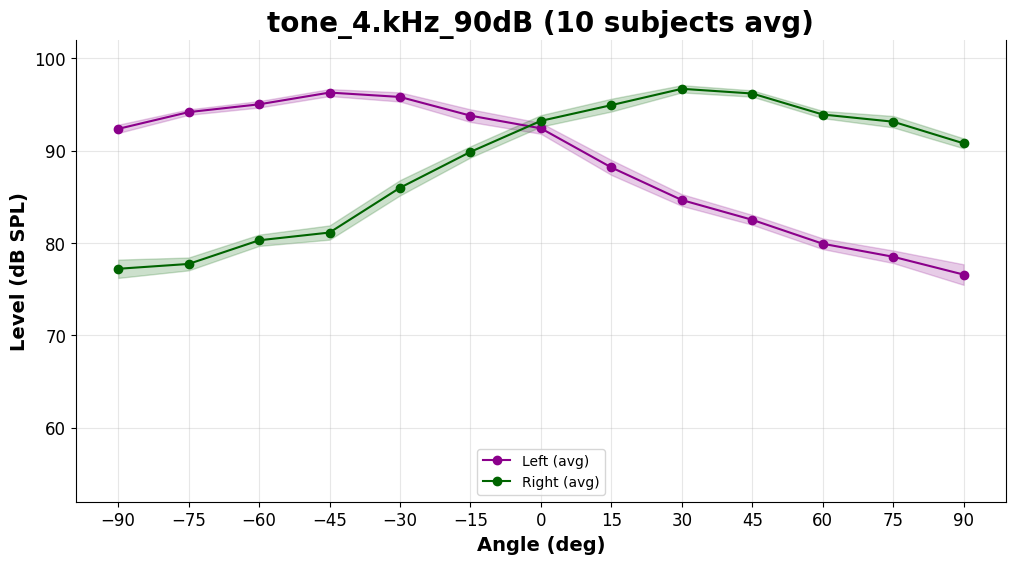

2025-12-18 17:01:39,583 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:39,584 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,587 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-18 17:01:39,589 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,590 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-18 17:01:39,591 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,593 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-18 17:01:39,594 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,599 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-18 17:01:39,600 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,603 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-18 17:01:39,603 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,605 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

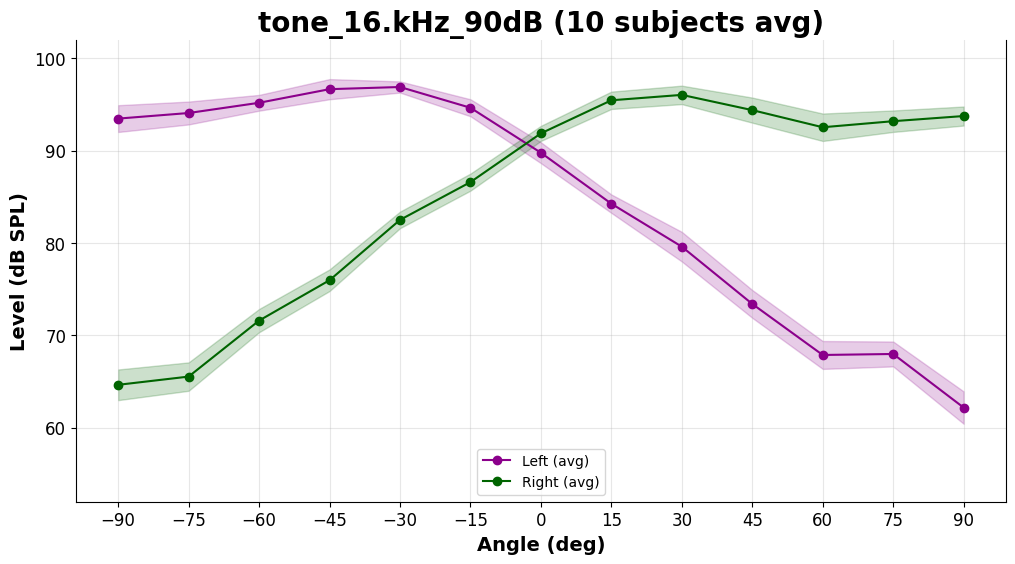

2025-12-18 17:01:39,970 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-18 17:01:39,971 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,974 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-18 17:01:39,975 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,976 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-18 17:01:39,978 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,981 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-18 17:01:39,982 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,986 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-18 17:01:39,987 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,990 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-18 17:01:39,991 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:01:39,992 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

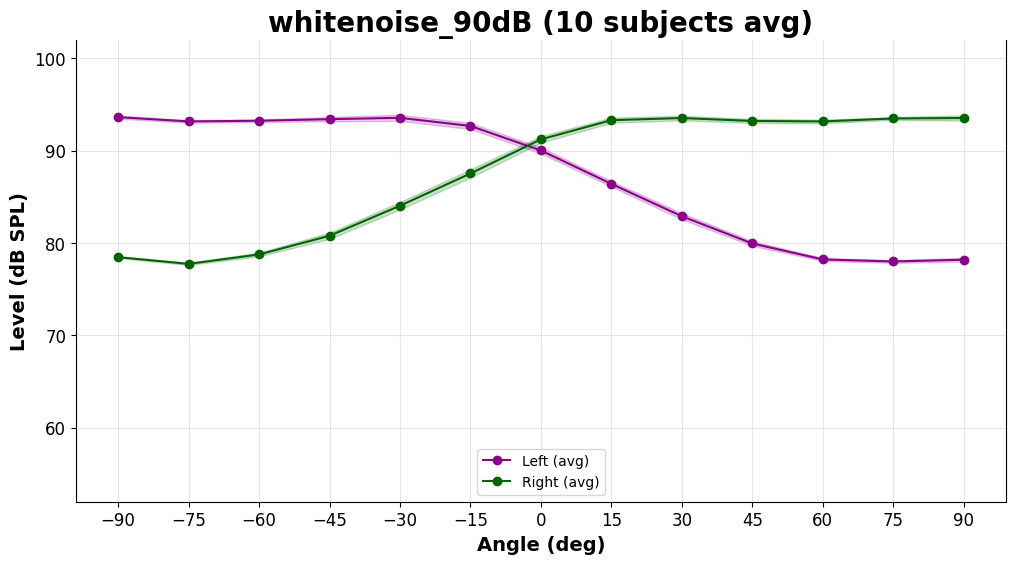

In [19]:
from scipy.stats import sem

for sound in inputs:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title(create_sound_key(sound) + f" ({len(subjects)} subjects avg)")


    # --- containers ---
    L_mean_all, R_mean_all = [], []
    L_sem_all,  R_sem_all  = [], []

    for angle in ANGLES:
        L_subj = []
        R_subj = []

        for subj in subjects:
            p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])

            L_subj.append(binaural[:, 0].level)
            R_subj.append(binaural[:, 1].level)

        L_subj = np.array(L_subj)
        R_subj = np.array(R_subj)

        # --- mean ---
        L_mean_all.append(L_subj.mean())
        R_mean_all.append(R_subj.mean())

        # --- SEM ---
        L_sem_all.append(sem(L_subj))
        R_sem_all.append(sem(R_subj))

    # convert to arrays
    L_mean_all = np.array(L_mean_all)
    R_mean_all = np.array(R_mean_all)

    L_sem_all = np.array(L_sem_all)
    R_sem_all = np.array(R_sem_all)

    # --- plotting means ---
    ax.plot(ANGLES, L_mean_all, "o-", color="darkmagenta", label="Left (avg)")
    ax.plot(ANGLES, R_mean_all, "o-", color="darkgreen", label="Right (avg)")

    # --- SEM shading ---
    ax.fill_between(
        ANGLES,
        L_mean_all - L_sem_all,
        L_mean_all + L_sem_all,
        color="darkmagenta",
        alpha=0.2
    )
    ax.fill_between(
        ANGLES,
        R_mean_all - R_sem_all,
        R_mean_all + R_sem_all,
        color="darkgreen",
        alpha=0.2
    )

    # --- cosmetics ---
    ax.set_xlabel("Angle (deg)")
    ax.set_ylabel("Level (dB SPL)")
    ax.set_ylim([52,102])
    ax.grid(True, alpha=0.3)
    ax.set_xticks(ANGLES)
    ax.legend(loc="lower center")

    plt.show()


In [23]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from utils.cochlea_utils import LSIDE_SOFA_ANGLES
# -------------------------
# Axes definitions
# -------------------------
angles = LSIDE_SOFA_ANGLES  # degrees
freqs = np.array([625, 1250, 1870, 2500, 3100,
                  3610, 4360, 5000, 5600, 6250])

A, F = np.meshgrid(angles, freqs)

ILD = np.zeros((len(freqs), len(angles)))

for f_idx, f in enumerate(freqs):
    sound = Tone(f * b2.Hz, TIME_SIMULATION * b2.ms, level)

    for a_idx, angle in enumerate(angles):
        L_subj = []
        R_subj = []

        for subj in subjects:
            p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj

            binaural, g = run_hrtf(
                sound,
                angle,
                p.cochlea[ZI_COC_KEY]['hrtf_params']
            )

            L_subj.append(binaural[:, 0].level)
            R_subj.append(binaural[:, 1].level)

        # subject average
        L_mean = np.mean(L_subj)
        R_mean = np.mean(R_subj)

        # ILD (negative values expected)
        ILD[f_idx, a_idx] =  R_mean - L_mean




2025-12-18 17:22:09,691 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=0
2025-12-18 17:22:09,693 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:22:09,694 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=1
2025-12-18 17:22:09,695 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:22:09,696 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=2
2025-12-18 17:22:09,697 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:22:09,700 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=3
2025-12-18 17:22:09,701 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:22:09,702 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=4
2025-12-18 17:22:09,703 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:22:09,705 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=5
2025-12-18 17:22:09,706 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-18 17:22:09,707 [DEBUG]  [run_hrtf] Starting HRTF for angle=0 subj=6
2025-12-18 

WARNING    /var/folders/ll/11knr8bs6_nbxy20yw3f5kfh0000gn/T/ipykernel_47396/3745175750.py:32: UserWarning:Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
 [py.warnings]


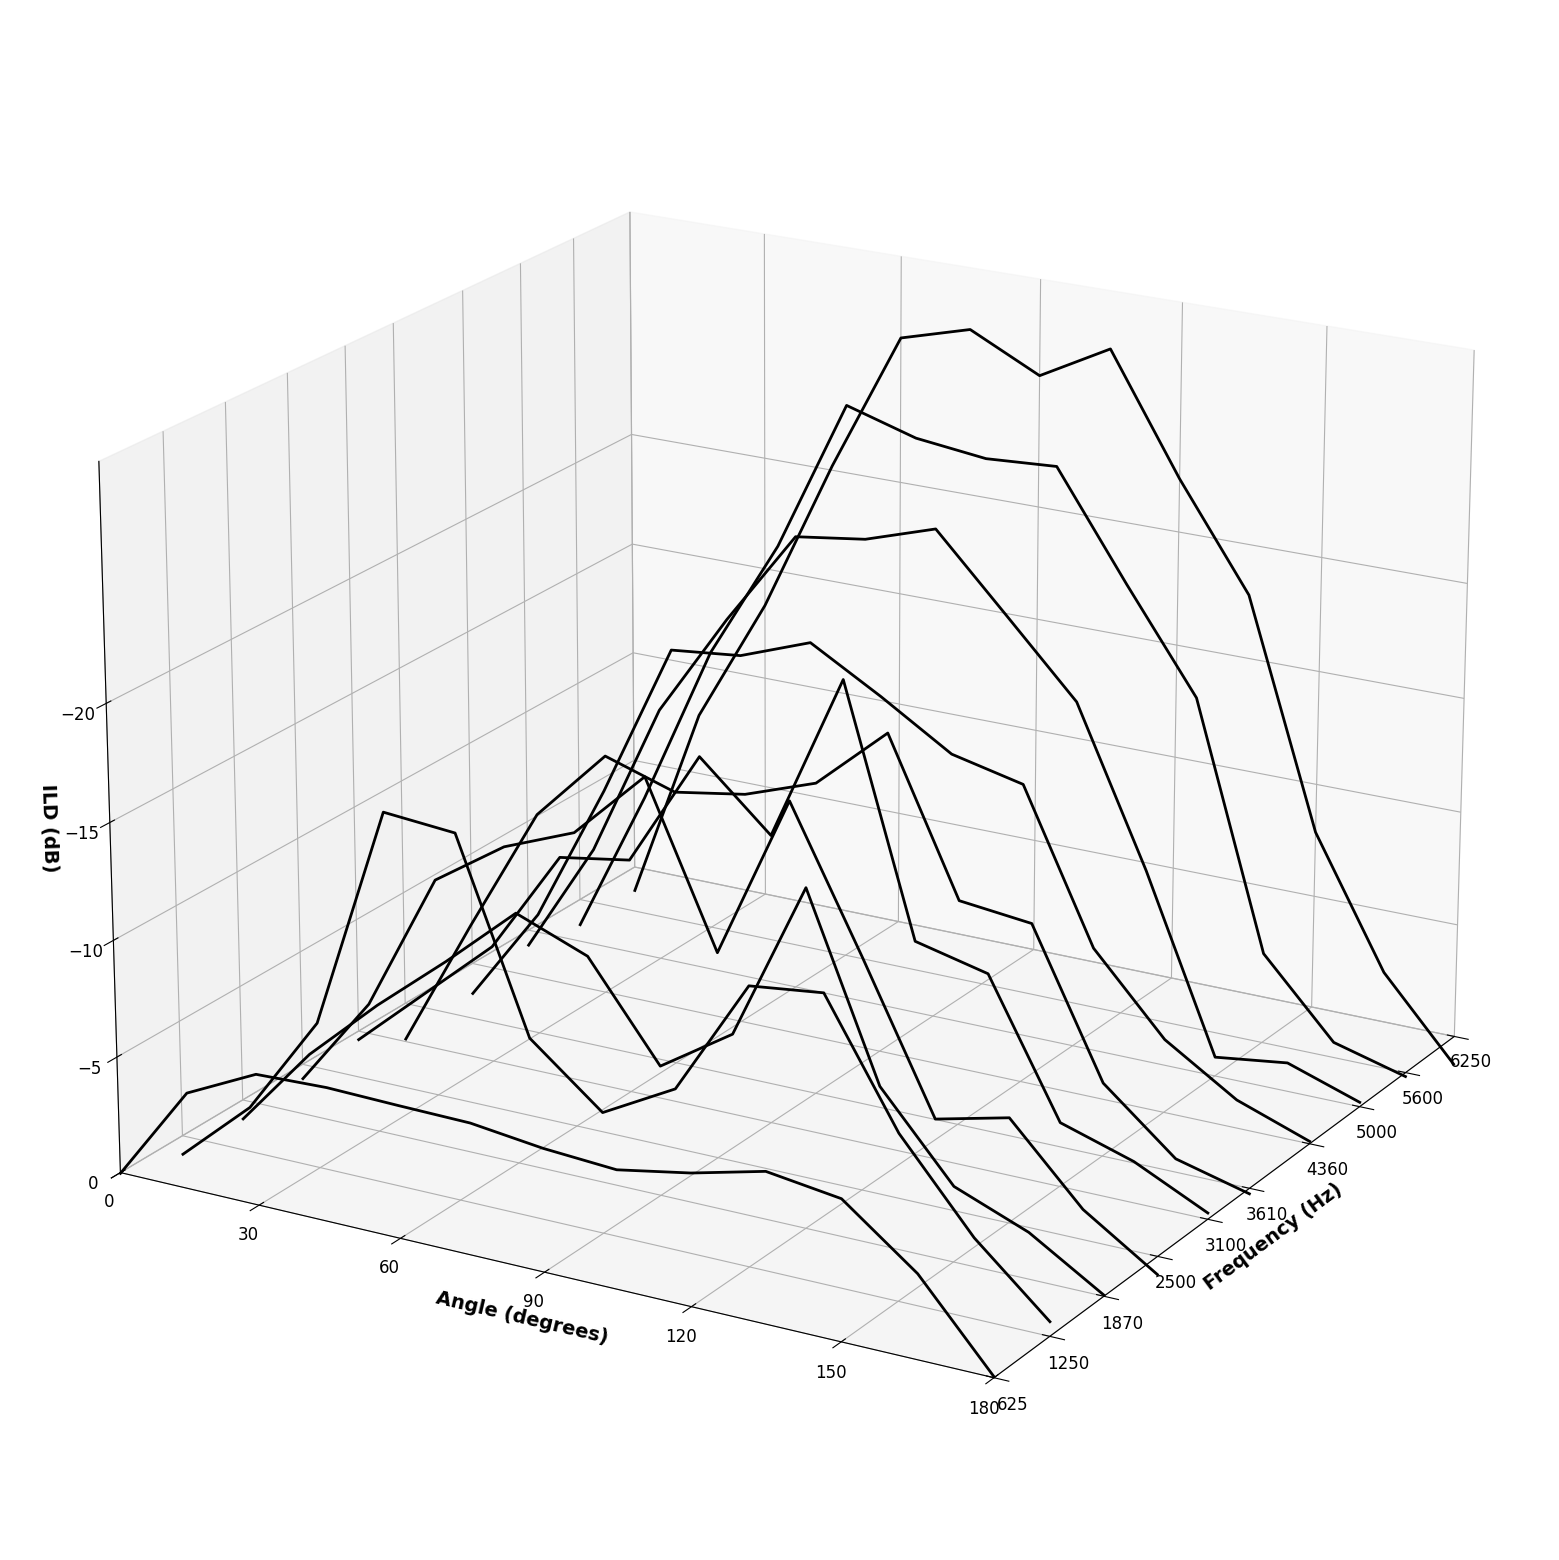

In [24]:
fig = plt.figure(figsize=(30,20))
ax = fig.add_subplot(111, projection="3d")

for f_idx, f in enumerate(freqs):
    ax.plot(
        np.full_like(angles, f),   # X axis: frequency (constant)
        angles,                    # Y axis: angle
        ILD[f_idx, :],              # Z axis: ILD
        linewidth=2,
        color = 'k'
    )


ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Angle (degrees)")
ax.set_zlabel("ILD (dB)")

ax.set_xlim(freqs.min(), freqs.max())
ax.set_xticks(freqs)
ax.set_xticklabels([str(f) for f in freqs])

ax.set_ylim(180,0)
ax.set_yticks(np.arange(0, 181, 30))

ax.set_zlim(0, -30)
ax.set_zticks([0, -5, -10, -15, -20])

# -------------------------
# View angle (planar emphasis)
# -------------------------
ax.view_init(elev=20, azim=210)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ILD heatmap (|ILD|), averaged across subjects
# x-axis: frontal angle [-90, +90] step 15 deg
# y-axis: pure tone frequency
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata



subjects = range(10)



# -------------------------
# Definitions
# -------------------------
TIME_SIMULATION = 250
level = 90 * b2h.dB

angles = np.arange(-90, 91, 15)  # deg
freqs_khz = np.array([0.125, 0.25, 0.5, 1])

tones = [
    Tone(f * b2.kHz, TIME_SIMULATION * b2.ms, level)
    for f in freqs_khz
]

#

2025-12-16 18:58:36,182 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=0
2025-12-16 18:58:36,184 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-16 18:58:36,188 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=1
2025-12-16 18:58:36,189 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-16 18:58:36,190 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=2
2025-12-16 18:58:36,190 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-16 18:58:36,192 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=3
2025-12-16 18:58:36,193 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-16 18:58:36,197 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=4
2025-12-16 18:58:36,198 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-16 18:58:36,201 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj=5
2025-12-16 18:58:36,202 [DEBUG]  [run_hrtf] Applying gating before HRTF...
2025-12-16 18:58:36,203 [DEBUG]  [run_hrtf] Starting HRTF for angle=-90 subj

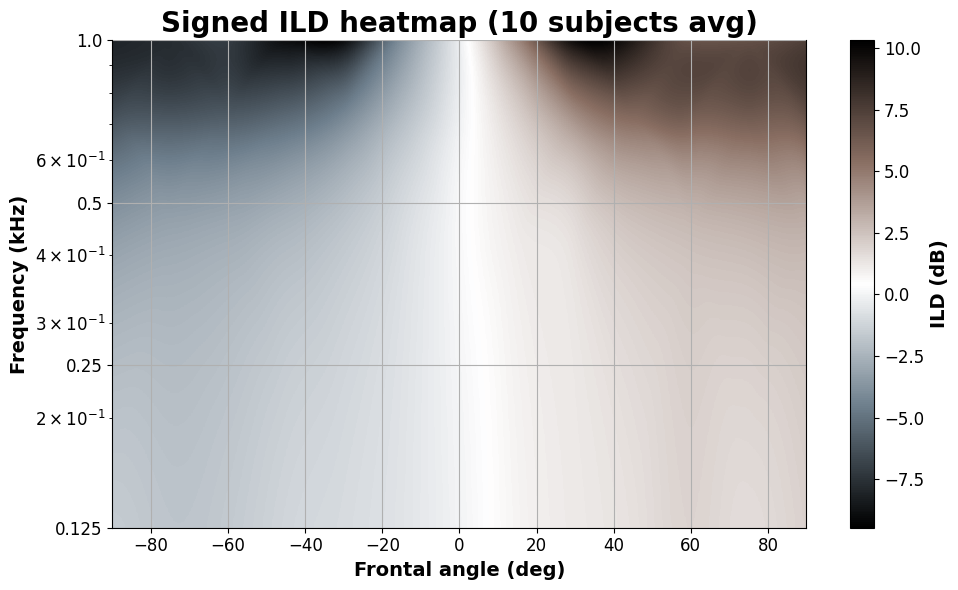

In [ ]:
# ============================================================
# Signed ILD heatmap
# white = 0 dB
# cold grey = negative ILD (L < R)
# warm grey = positive ILD (L > R)
# black = ±30 dB
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib import colors

# -------------------------
# Recompute SIGNED ILD (no abs)
# -------------------------
ILD_signed = np.zeros((len(freqs_khz), len(angles)))

for f_idx, sound in enumerate(tones):
    for a_idx, angle in enumerate(angles):
        L_subj = []
        R_subj = []

        for subj in subjects:
            p.cochlea[ZI_COC_KEY]['hrtf_params']['subj_number'] = subj
            binaural, g = run_hrtf(sound, angle, p.cochlea[ZI_COC_KEY]['hrtf_params'])

            L_subj.append(binaural[:, 0].level)
            R_subj.append(binaural[:, 1].level)

        L_subj = np.array(L_subj)
        R_subj = np.array(R_subj)

        ILD_signed[f_idx, a_idx] = (R_subj - L_subj).mean()

# -------------------------
# Interpolation
# -------------------------
A, F = np.meshgrid(angles, freqs_khz)
points = np.column_stack([A.ravel(), F.ravel()])
values = ILD_signed.ravel()

angle_i = np.linspace(angles.min(), angles.max(), 300)
freq_i  = np.logspace(np.log10(freqs_khz.min()),
                      np.log10(freqs_khz.max()), 300)

A_i, F_i = np.meshgrid(angle_i, freq_i)

ILD_i = griddata(points, values, (A_i, F_i), method="cubic")

# -------------------------
# Custom diverging grey colormap
# cold grey (negative) -> white (0) -> warm grey (positive)
# black at both extremes
# -------------------------
cmap = colors.LinearSegmentedColormap.from_list(
    "cold_warm_grey",
    [
        (0.00, "#000000"),   # -30 dB (black)
        (0.25, "#6e7f8d"),   # cold grey
        (0.50, "#ffffff"),   # 0 dB (white)
        (0.75, "#8a6f63"),   # warm grey
        (1.00, "#000000"),   # +30 dB (black)
    ]
)

#norm = colors.TwoSlopeNorm(vmin=-20, vcenter=0, vmax=20)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    ILD_i,
    origin="lower",
    aspect="auto",
    extent=[angle_i.min(), angle_i.max(), freq_i.min(), freq_i.max()],
    cmap=cmap,
    #norm=norm
)

ax.set_xlabel("Frontal angle (deg)")
ax.set_ylabel("Frequency (kHz)")
ax.set_yscale("log")
ax.set_yticks(freqs_khz)
ax.set_yticklabels(freqs_khz)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("ILD (dB)")

ax.set_title(f"Signed ILD heatmap ({len(subjects)} subjects avg)")

plt.tight_layout()
plt.show()
